In [1]:
# Check spaCy installation

try:
    import spacy
    print(f"spaCy version: {spacy.__version__}")
except ImportError:
    print("spaCy not installed. Run in Anaconda Prompt:")
    print("  pip install spacy")
    raise

try:
    nlp = spacy.load("en_core_web_sm")
    print("English model loaded ✓")
    print(f"Model: {nlp.meta['name']} v{nlp.meta['version']}")
except OSError:
    print("English model missing. Run in Anaconda Prompt:")
    print("  python -m spacy download en_core_web_sm")

spaCy not installed. Run in Anaconda Prompt:
  pip install spacy


ModuleNotFoundError: No module named 'spacy'

In [5]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 7.4 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.8 MB 7.4 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.8 MB 7.4 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 4.8 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 5.6 MB/s eta 0:00:02
     ---------------------- ----------------- 7.3/12.8 MB 6.0 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.8 MB 6.4 MB/s eta 0:00:01
     ---------------------------------- ----- 11.0/12.8 MB 6.7 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 6.8 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.7 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [6]:
# Phase B - Step 1: Inspect the narratives table structure
import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

# Get table structure
df_sample = pd.read_sql("SELECT TOP 3 * FROM narratives", conn)

print(f"narratives table - {len(df_sample.columns)} columns:")
for col in df_sample.columns:
    print(f"  - {col}")

print("\n--- Sample row ---")
for col in df_sample.columns:
    val = df_sample.iloc[0][col]
    if isinstance(val, str) and len(val) > 200:
        val = val[:200] + '...'
    print(f"\n{col}:")
    print(f"  {val}")

# Total count
total = pd.read_sql("SELECT COUNT(*) as n FROM narratives", conn).iloc[0]['n']
print(f"\n\nTotal narratives in table: {total:,}")

conn.close()

narratives table - 8 columns:
  - ev_id
  - Aircraft_Key
  - narr_accp
  - narr_accf
  - narr_cause
  - narr_inc
  - lchg_date
  - lchg_userid

--- Sample row ---

ev_id:
  20080211X00175

Aircraft_Key:
  1

narr_accp:
  import

narr_accf:
  None

narr_cause:
  None

narr_inc:
  None

lchg_date:
  2025-09-23 18:50:18

lchg_userid:
  dobn


Total narratives in table: 27,877


C:\Users\user\AppData\Local\Temp\ipykernel_14368\654903055.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sample = pd.read_sql("SELECT TOP 3 * FROM narratives", conn)
C:\Users\user\AppData\Local\Temp\ipykernel_14368\654903055.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  total = pd.read_sql("SELECT COUNT(*) as n FROM narratives", conn).iloc[0]['n']


In [7]:
# Phase B - Step 2: How many rows actually have meaningful narrative text?
import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

df = pd.read_sql("""
    SELECT ev_id, narr_accp, narr_accf, narr_cause, narr_inc
    FROM narratives
""", conn)
conn.close()

print(f"Total rows: {len(df):,}")
print()

# Length statistics for each text column
for col in ['narr_accp', 'narr_accf', 'narr_cause', 'narr_inc']:
    df[f'{col}_len'] = df[col].fillna('').astype(str).str.len()
    
    # Categorize
    n_null = df[col].isna().sum()
    n_empty = (df[col].fillna('').astype(str).str.strip() == '').sum()
    n_short = ((df[f'{col}_len'] > 0) & (df[f'{col}_len'] <= 50)).sum()
    n_meaningful = (df[f'{col}_len'] > 50).sum()
    
    print(f"{col}:")
    print(f"  Null: {n_null:>6,}  Empty: {n_empty - n_null:>6,}  Short (<50 char): {n_short:>6,}  Meaningful (>50 char): {n_meaningful:>6,}")
    if n_meaningful > 0:
        avg_len = df[df[f'{col}_len'] > 50][f'{col}_len'].mean()
        print(f"  Mean length (meaningful only): {avg_len:.0f} chars")
    print()

C:\Users\user\AppData\Local\Temp\ipykernel_14368\1185594862.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Total rows: 27,877

narr_accp:
  Null:  3,731  Empty:      0  Short (<50 char):     24  Meaningful (>50 char): 24,122
  Mean length (meaningful only): 4010 chars

narr_accf:
  Null:  3,467  Empty:      0  Short (<50 char):    195  Meaningful (>50 char): 24,215
  Mean length (meaningful only): 1224 chars

narr_cause:
  Null:  3,485  Empty:      0  Short (<50 char):    650  Meaningful (>50 char): 23,742
  Mean length (meaningful only): 162 chars

narr_inc:
  Null: 27,877  Empty:      0  Short (<50 char):      0  Meaningful (>50 char):      0



In [8]:
# Phase B - Step 3: Sample real cause statements
# Question: What does a typical NTSB probable cause statement look like?

import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

df = pd.read_sql("""
    SELECT ev_id, narr_cause
    FROM narratives
    WHERE narr_cause IS NOT NULL
""", conn)
conn.close()

# Filter to rows with real text
df['len'] = df['narr_cause'].astype(str).str.len()
df_real = df[df['len'] > 50].copy()

print(f"Total cause statements with meaningful text: {len(df_real):,}")
print(f"Mean length: {df_real['len'].mean():.0f} chars")
print(f"Median length: {df_real['len'].median():.0f} chars")
print(f"Max length: {df_real['len'].max():,} chars")
print()
print("=" * 80)
print("RANDOM 10 CAUSE STATEMENTS:")
print("=" * 80)

# Random sample
sample = df_real.sample(10, random_state=42)
for i, row in enumerate(sample.itertuples(), 1):
    print(f"\n[{i}] Event: {row.ev_id} ({row.len} chars)")
    print(f"   {row.narr_cause}")

C:\Users\user\AppData\Local\Temp\ipykernel_14368\2120144410.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Total cause statements with meaningful text: 23,742
Mean length: 162 chars
Median length: 138 chars
Max length: 3,232 chars

RANDOM 10 CAUSE STATEMENTS:

[1] Event: 20101109X12401 (91 chars)
   The pilot/mechanic’s improper inspection of the airplane following the engine installation.

[2] Event: 20230403106999 (197 chars)
   The flight instructor’s failure to maintain clearance from a commercial airliner which resulted in an encounter with wake turbulence and subsequent loss of control resulting in impact with terrain.

[3] Event: 20130904X05544 (291 chars)
   Maintenance personnel’s inadequate inspection and compliance with a Federal Aviation Administration airworthiness directive, which resulted in an undetected corroded and cracked stabilator turnbuckle and the subsequent failure of the turnbuckle and loss of elevator control during takeoff.


[4] Event: 20180829X90853 (103 chars)
   The pilot’s failure to maintain directional control during landing in gusting crosswind conditions.

In [9]:
# Phase B - Step 4: Extract grammatical subject of every cause statement
# Question: Across all 23,742 cause statements, who is the subject?

import pandas as pd
import pyodbc
import spacy
from collections import Counter

# Load spaCy
nlp = spacy.load("en_core_web_sm")

# Load cause statements
mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT ev_id, narr_cause
    FROM narratives
    WHERE narr_cause IS NOT NULL
""", conn)
conn.close()

df['len'] = df['narr_cause'].astype(str).str.len()
df = df[df['len'] > 50].copy().reset_index(drop=True)
print(f"Cause statements to analyze: {len(df):,}")
print()

# Function: extract head noun of the first noun-phrase that begins the statement
# Strategy: parse the sentence, find the root, then get its 'nsubj' (nominal subject)
# OR: find the first NP at the start (more robust for "The pilot's failure..." pattern)

def extract_first_subject(text):
    """Return the head noun of the leading subject phrase."""
    text = str(text).strip()
    if len(text) < 5:
        return None
    
    doc = nlp(text)
    
    # Strategy 1: find first noun chunk
    for chunk in doc.noun_chunks:
        head = chunk.root.lemma_.lower()
        # Skip leading articles/determiners
        if head not in ('the', 'a', 'an'):
            return head
    
    return None

# Test on first 5
print("Testing on first 5 statements:")
print("=" * 80)
for i in range(5):
    text = df.iloc[i]['narr_cause']
    subj = extract_first_subject(text)
    snippet = text[:120] + ('...' if len(text) > 120 else '')
    print(f"[{i+1}] subject = {subj!r}")
    print(f"    text: {snippet}")
    print()

C:\Users\user\AppData\Local\Temp\ipykernel_14368\431968078.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Cause statements to analyze: 23,742

Testing on first 5 statements:
[1] subject = 'lookout'
    text: The departing pilot's inadequate visual lookout.



[2] subject = 'failure'
    text: The pilot's failure to maintain directional control.  A contributing factor was the prevailing crosswind.

[3] subject = 'failure'
    text: The line technician's failure to remain clear of the propeller.  A factor was the night lighting conditions.

[4] subject = 'flare'
    text: the student pilot's premature flare resulting in the loss of aircraft control.

[5] subject = 'failure'
    text: The pilot's failure to follow the checklist and failure to achieve the proper touchdown point during a forced landing. C...



In [10]:
# Phase B - Step 4 (revised): Extract the ATTRIBUTED ACTOR
# Pattern: "The [actor]'s [action]" or "The [action] of the [actor]"

import re
import spacy
import pandas as pd
import pyodbc

nlp = spacy.load("en_core_web_sm")

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT ev_id, narr_cause
    FROM narratives
    WHERE narr_cause IS NOT NULL
""", conn)
conn.close()

df['len'] = df['narr_cause'].astype(str).str.len()
df = df[df['len'] > 50].copy().reset_index(drop=True)


def extract_actor(text):
    """
    Extract the actor (the attributed agent) from a probable-cause statement.
    Tries two patterns:
      1. "The [ACTOR]'s [action]"  -> possessive
      2. "[Action] of the [ACTOR]" -> of-phrase
    Returns lowercase head noun of the actor, or None.
    """
    text = str(text).strip()
    if len(text) < 5:
        return None
    
    doc = nlp(text)
    
    # Strategy 1: find a token with 'poss' dependency (possessor of something)
    # This catches "The pilot 's failure" where 'pilot' has dep_='poss'
    for token in doc:
        if token.dep_ == 'poss' and token.pos_ in ('NOUN', 'PROPN'):
            return token.lemma_.lower()
    
    # Strategy 2: find "X of Y" pattern - failure OF the pilot
    # Look for prep 'of' attached to a head noun, then find its pobj
    for token in doc:
        if token.text.lower() == 'of' and token.dep_ == 'prep':
            for child in token.children:
                if child.dep_ == 'pobj' and child.pos_ in ('NOUN', 'PROPN'):
                    return child.lemma_.lower()
    
    # Fallback: first non-determiner noun
    for chunk in doc.noun_chunks:
        head = chunk.root
        if head.lemma_.lower() not in ('the', 'a', 'an'):
            return head.lemma_.lower()
    
    return None


# Test on first 10
print("Testing actor extraction on first 10 statements:")
print("=" * 80)
for i in range(10):
    text = df.iloc[i]['narr_cause']
    actor = extract_actor(text)
    snippet = text[:120] + ('...' if len(text) > 120 else '')
    print(f"[{i+1}] actor = {actor!r}")
    print(f"    text: {snippet}")
    print()

C:\Users\user\AppData\Local\Temp\ipykernel_14368\2497493653.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Testing actor extraction on first 10 statements:
[1] actor = 'pilot'
    text: The departing pilot's inadequate visual lookout.



[2] actor = 'pilot'
    text: The pilot's failure to maintain directional control.  A contributing factor was the prevailing crosswind.

[3] actor = 'technician'
    text: The line technician's failure to remain clear of the propeller.  A factor was the night lighting conditions.

[4] actor = 'pilot'
    text: the student pilot's premature flare resulting in the loss of aircraft control.

[5] actor = 'pilot'
    text: The pilot's failure to follow the checklist and failure to achieve the proper touchdown point during a forced landing. C...

[6] actor = 'airplane'
    text: The failure of company maintenance personnel to ensure that the airplane's nose baggage door latching mechanism was prop...

[7] actor = 'power'
    text: A loss of engine power due to inadequate maintenance inspection resulting in a worn throttle housing going undetected an...

[8] actor

In [11]:
# Phase B - Step 5: Apply actor extraction to all 23,742 cause statements

import re
import spacy
import pandas as pd
import pyodbc
from collections import Counter
from tqdm.notebook import tqdm

nlp = spacy.load("en_core_web_sm")

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT ev_id, narr_cause
    FROM narratives
    WHERE narr_cause IS NOT NULL
""", conn)
conn.close()

df['len'] = df['narr_cause'].astype(str).str.len()
df = df[df['len'] > 50].copy().reset_index(drop=True)
print(f"Statements to process: {len(df):,}")
print()


def extract_actor(text):
    """Extract attributed actor from a probable-cause statement."""
    text = str(text).strip()
    if len(text) < 5:
        return None
    
    doc = nlp(text)
    
    # Strategy 1: 'poss' dependency (X's failure)
    for token in doc:
        if token.dep_ == 'poss' and token.pos_ in ('NOUN', 'PROPN'):
            return token.lemma_.lower()
    
    # Strategy 2: 'of [actor]' pattern (failure of the X)
    for token in doc:
        if token.text.lower() == 'of' and token.dep_ == 'prep':
            for child in token.children:
                if child.dep_ == 'pobj' and child.pos_ in ('NOUN', 'PROPN'):
                    return child.lemma_.lower()
    
    # Fallback: first non-determiner noun
    for chunk in doc.noun_chunks:
        head = chunk.root
        if head.lemma_.lower() not in ('the', 'a', 'an'):
            return head.lemma_.lower()
    
    return None


# Process — uses spaCy's nlp.pipe for speed (much faster than calling nlp() in a loop)
print("Processing... (estimated 5-10 minutes)")
texts = df['narr_cause'].astype(str).tolist()

actors = []
for doc in tqdm(nlp.pipe(texts, batch_size=100), total=len(texts)):
    actor = None
    
    # Strategy 1: poss
    for token in doc:
        if token.dep_ == 'poss' and token.pos_ in ('NOUN', 'PROPN'):
            actor = token.lemma_.lower()
            break
    
    # Strategy 2: of-pattern
    if actor is None:
        for token in doc:
            if token.text.lower() == 'of' and token.dep_ == 'prep':
                for child in token.children:
                    if child.dep_ == 'pobj' and child.pos_ in ('NOUN', 'PROPN'):
                        actor = child.lemma_.lower()
                        break
                if actor:
                    break
    
    # Fallback: first noun chunk
    if actor is None:
        for chunk in doc.noun_chunks:
            head = chunk.root
            if head.lemma_.lower() not in ('the', 'a', 'an'):
                actor = head.lemma_.lower()
                break
    
    actors.append(actor)

df['actor'] = actors

# Top 50 most common actors
print("\n" + "=" * 60)
print("TOP 50 MOST COMMON ATTRIBUTED ACTORS")
print("=" * 60)
counter = Counter(actors)
total = sum(counter.values())
for i, (word, count) in enumerate(counter.most_common(50), 1):
    pct = count / total * 100
    print(f"{i:>3}. {word:<25s} {count:>6,}  ({pct:>5.2f}%)")

# Save for later analysis
df[['ev_id', 'narr_cause', 'actor']].to_csv('phase_b_actors.csv', index=False)
print("\n\n✅ Saved: phase_b_actors.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_14368\2605995125.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Statements to process: 23,742

Processing... (estimated 5-10 minutes)


  0%|          | 0/23742 [00:00<?, ?it/s]


TOP 50 MOST COMMON ATTRIBUTED ACTORS
  1. pilot                     15,795  (66.53%)
  2. power                      2,150  ( 9.06%)
  3. instructor                   601  ( 2.53%)
  4. airplane                     508  ( 2.14%)
  5. control                      386  ( 1.63%)
  6. personnel                    226  ( 0.95%)
  7. crew                         223  ( 0.94%)
  8. gear                         187  ( 0.79%)
  9. engine                       130  ( 0.55%)
 10. encounter                    130  ( 0.55%)
 11. controller                   113  ( 0.48%)
 12. flight                       107  ( 0.45%)
 13. mechanic                     105  ( 0.44%)
 14. instruction                   99  ( 0.42%)
 15. operator                      78  ( 0.33%)
 16. failure                       77  ( 0.32%)
 17. collision                     72  ( 0.30%)
 18. captain                       71  ( 0.30%)
 19. system                        68  ( 0.29%)
 20. passenger                     63  ( 0.27%)
 2

In [12]:
# Phase B - Step 6: Improve actor extraction
# Filter out "action nouns" (failure, encounter, etc.) - these are NOT actors

import re
import spacy
import pandas as pd
import pyodbc
from collections import Counter
from tqdm.notebook import tqdm

nlp = spacy.load("en_core_web_sm")

# Action nouns (not actors) - words that mean "the act of doing X"
ACTION_NOUNS = {
    'failure', 'inability', 'loss', 'lack', 'absence',
    'encounter', 'collision', 'impact', 'landing', 'takeoff',
    'departure', 'approach', 'arrival',
    'instruction', 'misjudgment', 'misperception', 'mismanagement',
    'exceedance', 'deviation', 'omission', 'violation',
    'separation', 'continuation', 'application',
    'attempt', 'decision', 'action',
    'response', 'use', 'operation',
}

# Mechanical/structural nouns - non-human cause (will be categorized separately)
MECHANICAL_NOUNS = {
    'power', 'gear', 'engine', 'system', 'brake', 'blade', 'valve',
    'cable', 'bolt', 'rod', 'cylinder', 'pump', 'actuator', 'pressure',
    'spring', 'bearing', 'strut', 'wing', 'assembly', 'control',
    'fire', 'fuel', 'tank', 'line', 'rotor', 'propeller', 'shaft',
    'wheel', 'tire', 'aileron', 'elevator', 'rudder', 'flap',
    'hydraulic', 'electrical', 'pneumatic',
    'airplane', 'aircraft', 'helicopter', 'glider',
}

# Human actor nouns (whitelist for clearer classification)
HUMAN_INDIVIDUAL = {
    'pilot', 'instructor', 'mechanic', 'technician', 'engineer',
    'controller', 'crew', 'flightcrew', 'crewmember',
    'captain', 'officer', 'attendant',
    'student', 'trainee',
    'passenger', 'driver', 'operator', 'owner', 'builder',
    'personnel', 'inspector', 'supervisor', 'observer',
    'pilot/mechanic',
}

# Organizational actor nouns
ORGANIZATIONAL = {
    'manufacturer', 'company', 'operator', 'airline', 'carrier',
    'organization', 'employer', 'department', 'agency',
    'faa', 'ntsb', 'government', 'school', 'school',
    'corporation', 'firm',
    'maintenance',  # often "maintenance personnel" — context-dependent
}


def extract_actor_v2(doc):
    """
    Improved extraction: 
    - Skip action nouns
    - Return the FIRST valid actor (poss > of-pattern > fallback)
    - Track if it's mechanical / human / organizational / unknown
    """
    candidates = []
    
    # Strategy 1: collect ALL poss tokens (in order)
    for token in doc:
        if token.dep_ == 'poss' and token.pos_ in ('NOUN', 'PROPN'):
            lemma = token.lemma_.lower()
            if lemma not in ACTION_NOUNS:
                candidates.append(('poss', lemma))
    
    # Strategy 2: 'of [actor]' patterns
    for token in doc:
        if token.text.lower() == 'of' and token.dep_ == 'prep':
            for child in token.children:
                if child.dep_ == 'pobj' and child.pos_ in ('NOUN', 'PROPN'):
                    lemma = child.lemma_.lower()
                    if lemma not in ACTION_NOUNS:
                        candidates.append(('of', lemma))
    
    # Strategy 3: noun chunks fallback
    if not candidates:
        for chunk in doc.noun_chunks:
            head = chunk.root
            lemma = head.lemma_.lower()
            if lemma not in ('the', 'a', 'an') and lemma not in ACTION_NOUNS:
                candidates.append(('chunk', lemma))
                break
    
    if not candidates:
        return (None, 'none')
    
    # Pick the first candidate (priority: poss > of > chunk)
    actor = candidates[0][1]
    
    # Categorize
    if actor in HUMAN_INDIVIDUAL:
        category = 'individual'
    elif actor in ORGANIZATIONAL:
        category = 'organizational'
    elif actor in MECHANICAL_NOUNS:
        category = 'mechanical'
    else:
        category = 'other'
    
    return (actor, category)


# Re-process all
mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT ev_id, narr_cause
    FROM narratives
    WHERE narr_cause IS NOT NULL
""", conn)
conn.close()

df['len'] = df['narr_cause'].astype(str).str.len()
df = df[df['len'] > 50].copy().reset_index(drop=True)

print(f"Re-processing {len(df):,} statements with improved extraction...")
texts = df['narr_cause'].astype(str).tolist()

results = []
for doc in tqdm(nlp.pipe(texts, batch_size=100), total=len(texts)):
    actor, category = extract_actor_v2(doc)
    results.append((actor, category))

df['actor_v2'] = [r[0] for r in results]
df['actor_category'] = [r[1] for r in results]

# Summary by category
print("\n" + "=" * 60)
print("CATEGORY DISTRIBUTION (improved extraction)")
print("=" * 60)
cat_counts = df['actor_category'].value_counts()
for cat, count in cat_counts.items():
    pct = count / len(df) * 100
    print(f"  {cat:<15s}: {count:>6,}  ({pct:>5.2f}%)")

print("\n" + "=" * 60)
print("TOP 30 actors by category")
print("=" * 60)
for cat in ['individual', 'organizational', 'mechanical', 'other']:
    sub = df[df['actor_category'] == cat]
    if len(sub) == 0:
        continue
    print(f"\n--- {cat.upper()} (total {len(sub):,}) ---")
    counter = Counter(sub['actor_v2'].dropna())
    for word, count in counter.most_common(15):
        print(f"  {word:<25s} {count:>6,}")

# Save
df[['ev_id', 'narr_cause', 'actor_v2', 'actor_category']].to_csv('phase_b_actors_v2.csv', index=False)
print("\n✅ Saved: phase_b_actors_v2.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_14368\2954376904.py:117: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Re-processing 23,742 statements with improved extraction...


  0%|          | 0/23742 [00:00<?, ?it/s]


CATEGORY DISTRIBUTION (improved extraction)
  individual     : 17,566  (73.99%)
  mechanical     :  4,152  (17.49%)
  other          :  1,922  ( 8.10%)
  organizational :     99  ( 0.42%)
  none           :      3  ( 0.01%)

TOP 30 actors by category

--- INDIVIDUAL (total 17,566) ---
  pilot                     15,826
  instructor                   652
  personnel                    226
  crew                         224
  controller                   113
  mechanic                     105
  operator                      78
  captain                       73
  passenger                     63
  owner                         49
  builder                       35
  driver                        28
  attendant                     23
  flightcrew                    20
  student                       18

--- ORGANIZATIONAL (total 99) ---
  manufacturer                  58
  government                    35
  company                        3
  faa                            2
  school     

In [13]:
# Phase B - Step 7: Random validation (n=100 manual check)
# Sample 100 random statements + their extracted actors for visual inspection

import pandas as pd

df = pd.read_csv('phase_b_actors_v2.csv')

# Random sample 100, stratified by category if possible
sample = df.sample(100, random_state=42).reset_index(drop=True)

print("=" * 100)
print("RANDOM SAMPLE FOR MANUAL VALIDATION (n=100)")
print("=" * 100)
print()

for i, row in sample.iterrows():
    text = row['narr_cause']
    if len(text) > 200:
        text = text[:200] + '...'
    print(f"[{i+1:>3}] category={row['actor_category']:<14s} actor={str(row['actor_v2']):<20s}")
    print(f"      {text}")
    print()

# Save
sample.to_csv('phase_b_validation_sample.csv', index=False)
print("✅ Saved: phase_b_validation_sample.csv")
print()
print("Now: open the CSV in Excel/Numbers, add a column 'correct?' (Y/N),")
print("and compute accuracy. Or just scan the printout above.")

RANDOM SAMPLE FOR MANUAL VALIDATION (n=100)

[  1] category=individual     actor=mechanic            
      The pilot/mechanic’s improper inspection of the airplane following the engine installation.

[  2] category=individual     actor=instructor          
      The flight instructor’s failure to maintain clearance from a commercial airliner which resulted in an encounter with wake turbulence and subsequent loss of control resulting in impact with terrain.

[  3] category=individual     actor=personnel           
      Maintenance personnel’s inadequate inspection and compliance with a Federal Aviation Administration airworthiness directive, which resulted in an undetected corroded and cracked stabilator turnbuckle ...

[  4] category=individual     actor=pilot               
      The pilot’s failure to maintain directional control during landing in gusting crosswind conditions.



[  5] category=individual     actor=pilot               
      The pilot’s exceedance of the biplane’s 

In [14]:
# Phase B - Step 8: Main clause vs Contributing clause analysis
# Question: Does pilot dominate the main cause clause and 
# organizational issues appear only in "contributing" clauses?

import re
import spacy
import pandas as pd
import pyodbc
from collections import Counter
from tqdm.notebook import tqdm

nlp = spacy.load("en_core_web_sm")

# Reuse our category whitelists from Step 6
ACTION_NOUNS = {
    'failure', 'inability', 'loss', 'lack', 'absence',
    'encounter', 'collision', 'impact', 'landing', 'takeoff',
    'departure', 'approach', 'arrival',
    'instruction', 'misjudgment', 'misperception', 'mismanagement',
    'exceedance', 'deviation', 'omission', 'violation',
    'separation', 'continuation', 'application',
    'attempt', 'decision', 'action',
    'response', 'use', 'operation',
}
MECHANICAL_NOUNS = {
    'power', 'gear', 'engine', 'system', 'brake', 'blade', 'valve',
    'cable', 'bolt', 'rod', 'cylinder', 'pump', 'actuator', 'pressure',
    'spring', 'bearing', 'strut', 'wing', 'assembly', 'control',
    'fire', 'fuel', 'tank', 'line', 'rotor', 'propeller', 'shaft',
    'wheel', 'tire', 'aileron', 'elevator', 'rudder', 'flap',
    'hydraulic', 'electrical', 'pneumatic',
    'airplane', 'aircraft', 'helicopter', 'glider',
}
HUMAN_INDIVIDUAL = {
    'pilot', 'instructor', 'mechanic', 'technician', 'engineer',
    'controller', 'crew', 'flightcrew', 'crewmember',
    'captain', 'officer', 'attendant',
    'student', 'trainee',
    'passenger', 'driver', 'operator', 'owner', 'builder',
    'personnel', 'inspector', 'supervisor', 'observer',
}
ORGANIZATIONAL = {
    'manufacturer', 'company', 'airline', 'carrier',
    'organization', 'employer', 'department', 'agency',
    'faa', 'ntsb', 'government', 'school',
    'corporation', 'firm', 'maintenance',
}


def categorize(actor):
    if actor is None:
        return 'none'
    actor = actor.lower()
    if actor in HUMAN_INDIVIDUAL:
        return 'individual'
    if actor in ORGANIZATIONAL:
        return 'organizational'
    if actor in MECHANICAL_NOUNS:
        return 'mechanical'
    return 'other'


def split_main_contributing(text):
    """
    Split a probable cause statement into main and contributing parts.
    NTSB convention: 'Contributing to/were/was' or 'Also contributing' starts contributing clause.
    """
    text = str(text).strip()
    # Patterns NTSB uses
    patterns = [
        r'\bContributing to\b',
        r'\bContributing was\b',
        r'\bContributing were\b',
        r'\bAlso contributing\b',
        r'\bA contributing factor\b',
        r'\bContributing factors\b',
        r'\bContributing to the accident\b',
    ]
    
    for pat in patterns:
        match = re.search(pat, text, re.IGNORECASE)
        if match:
            main = text[:match.start()].strip()
            contrib = text[match.start():].strip()
            return main, contrib
    
    return text, None  # no contributing clause found


def extract_actors_from_clause(clause):
    """Extract ALL actors (poss + of-pattern) from a clause, not just the first."""
    if not clause:
        return []
    doc = nlp(clause)
    actors = []
    
    # All poss tokens
    for token in doc:
        if token.dep_ == 'poss' and token.pos_ in ('NOUN', 'PROPN'):
            lemma = token.lemma_.lower()
            if lemma not in ACTION_NOUNS:
                actors.append(lemma)
    
    # All of-patterns
    for token in doc:
        if token.text.lower() == 'of' and token.dep_ == 'prep':
            for child in token.children:
                if child.dep_ == 'pobj' and child.pos_ in ('NOUN', 'PROPN'):
                    lemma = child.lemma_.lower()
                    if lemma not in ACTION_NOUNS:
                        actors.append(lemma)
    
    return actors


# Load data
mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT ev_id, narr_cause
    FROM narratives
    WHERE narr_cause IS NOT NULL
""", conn)
conn.close()
df['len'] = df['narr_cause'].astype(str).str.len()
df = df[df['len'] > 50].copy().reset_index(drop=True)

print(f"Processing {len(df):,} statements for clause split + actor extraction...")

main_actors_all = []
contrib_actors_all = []
has_contrib_count = 0

for text in tqdm(df['narr_cause'].astype(str).tolist()):
    main, contrib = split_main_contributing(text)
    main_actors = extract_actors_from_clause(main)
    contrib_actors = extract_actors_from_clause(contrib) if contrib else []
    
    main_actors_all.append(main_actors)
    contrib_actors_all.append(contrib_actors)
    if contrib:
        has_contrib_count += 1

df['main_actors'] = main_actors_all
df['contrib_actors'] = contrib_actors_all

print(f"\nStatements with a 'Contributing' clause: {has_contrib_count:,} ({has_contrib_count/len(df)*100:.1f}%)")
print(f"Statements WITHOUT a contributing clause: {len(df)-has_contrib_count:,}")
print()

# Categorize each appearance
def category_distribution(actor_lists):
    flat = [a for lst in actor_lists for a in lst]
    cats = [categorize(a) for a in flat]
    return Counter(cats), len(flat)

main_cats, main_total = category_distribution(main_actors_all)
contrib_cats, contrib_total = category_distribution(contrib_actors_all)

print("=" * 70)
print("ACTOR CATEGORY DISTRIBUTION: Main clause vs Contributing clause")
print("=" * 70)
print(f"\n{'Category':<18s} | {'Main':<20s} | {'Contributing':<20s}")
print("-" * 70)
for cat in ['individual', 'organizational', 'mechanical', 'other']:
    m_n = main_cats.get(cat, 0)
    c_n = contrib_cats.get(cat, 0)
    m_pct = m_n / main_total * 100 if main_total else 0
    c_pct = c_n / contrib_total * 100 if contrib_total else 0
    print(f"{cat:<18s} | {m_n:>6,} ({m_pct:>5.2f}%)  | {c_n:>6,} ({c_pct:>5.2f}%)")

print(f"\n{'TOTAL':<18s} | {main_total:>6,}             | {contrib_total:>6,}")

C:\Users\user\AppData\Local\Temp\ipykernel_14368\3287144287.py:123: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Processing 23,742 statements for clause split + actor extraction...


  0%|          | 0/23742 [00:00<?, ?it/s]


Statements with a 'Contributing' clause: 4,393 (18.5%)
Statements WITHOUT a contributing clause: 19,349

ACTOR CATEGORY DISTRIBUTION: Main clause vs Contributing clause

Category           | Main                 | Contributing        
----------------------------------------------------------------------
individual         | 17,577 (45.35%)  |  3,009 (47.36%)
organizational     |    135 ( 0.35%)  |    130 ( 2.05%)
mechanical         | 13,903 (35.87%)  |  1,035 (16.29%)
other              |  7,140 (18.42%)  |  2,180 (34.31%)

TOTAL              | 38,755             |  6,354


In [15]:
# Phase B - Step 9: Temporal trend in actor categories
# Question: Has individual attribution strengthened over time in cause statements?

import pandas as pd
import pyodbc
from collections import Counter

# Load the v2 results we already saved (saves 1.5 min spaCy re-run)
df = pd.read_csv('phase_b_actors_v2.csv')

# Join with events to get year
mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
events = pd.read_sql("SELECT ev_id, ev_date FROM events", conn)
conn.close()

# Merge
df = df.merge(events, on='ev_id', how='left')
df['year'] = pd.to_datetime(df['ev_date']).dt.year
df = df.dropna(subset=['year']).copy()
df['year'] = df['year'].astype(int)
df['year_bucket'] = (df['year'] // 5) * 5

print(f"Statements with year: {len(df):,}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")
print()

# Year-bucket × category breakdown
result = df.groupby(['year_bucket', 'actor_category']).size().unstack(fill_value=0)
result['total'] = result.sum(axis=1)

# Calculate %
for cat in ['individual', 'organizational', 'mechanical', 'other']:
    if cat in result.columns:
        result[f'{cat}_pct'] = result[cat] / result['total'] * 100

# Filter buckets with at least 100 statements (avoid noise)
result_filtered = result[result['total'] >= 100].copy()

print("=" * 80)
print("CATEGORY % BY 5-YEAR BUCKET")
print("=" * 80)
print(f"\n{'year':>6} | {'n':>5} | {'individual':>10} | {'org':>7} | {'mechanical':>10} | {'other':>7}")
print("-" * 80)
for year_b, row in result_filtered.iterrows():
    n = int(row['total'])
    ind = row.get('individual_pct', 0)
    org = row.get('organizational_pct', 0)
    mech = row.get('mechanical_pct', 0)
    oth = row.get('other_pct', 0)
    print(f"{year_b:>6} | {n:>5,} | {ind:>9.1f}% | {org:>6.2f}% | {mech:>9.1f}% | {oth:>6.1f}%")

# Save for later figure
result_filtered.to_csv('phase_b_temporal.csv')
print("\n✅ Saved: phase_b_temporal.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_14368\3340695372.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  events = pd.read_sql("SELECT ev_id, ev_date FROM events", conn)


Statements with year: 23,742
Year range: 2008 – 2026

CATEGORY % BY 5-YEAR BUCKET

  year |     n | individual |     org | mechanical |   other
--------------------------------------------------------------------------------
  2005 | 3,265 |      74.7% |   0.89% |      16.1% |    8.3%
  2010 | 7,383 |      74.1% |   0.60% |      17.4% |    7.8%
  2015 | 6,705 |      74.6% |   0.22% |      17.2% |    8.0%
  2020 | 5,772 |      71.7% |   0.16% |      19.4% |    8.7%
  2025 |   617 |      83.3% |   0.32% |      10.0% |    6.3%

✅ Saved: phase_b_temporal.csv


In [16]:
# Phase B - Step 10: Severity gradient
# Question: Does fatality affect actor distribution in cause statements?

import pandas as pd
import pyodbc
from collections import Counter

df = pd.read_csv('phase_b_actors_v2.csv')

# Get severity from events table
mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
events = pd.read_sql("""
    SELECT ev_id, ev_highest_injury, ev_date 
    FROM events 
    WHERE ev_highest_injury IS NOT NULL
""", conn)
conn.close()

# Merge
df = df.merge(events, on='ev_id', how='inner')
df['year'] = pd.to_datetime(df['ev_date']).dt.year
df = df[(df['year'] >= 2008) & (df['year'] <= 2024)].copy()  # restrict to clean window

print(f"Statements with severity (2008-2024): {len(df):,}")
print(f"\nInjury distribution:")
print(df['ev_highest_injury'].value_counts())
print()

# Severity × category
severity_order = ['NONE', 'MINR', 'SERS', 'FATL']
severity_labels = {'NONE': 'None', 'MINR': 'Minor', 'SERS': 'Serious', 'FATL': 'Fatal'}

result = df.groupby(['ev_highest_injury', 'actor_category']).size().unstack(fill_value=0)
result['total'] = result.sum(axis=1)
for cat in ['individual', 'organizational', 'mechanical', 'other']:
    if cat in result.columns:
        result[f'{cat}_pct'] = result[cat] / result['total'] * 100

print("=" * 80)
print("ACTOR CATEGORY % BY ACCIDENT SEVERITY")
print("=" * 80)
print(f"\n{'severity':<10} | {'n':>6} | {'individual':>10} | {'org':>7} | {'mechanical':>10} | {'other':>7}")
print("-" * 80)
for sev in severity_order:
    if sev not in result.index:
        continue
    row = result.loc[sev]
    n = int(row['total'])
    ind = row.get('individual_pct', 0)
    org = row.get('organizational_pct', 0)
    mech = row.get('mechanical_pct', 0)
    oth = row.get('other_pct', 0)
    print(f"{severity_labels[sev]:<10} | {n:>6,} | {ind:>9.2f}% | {org:>6.2f}% | {mech:>9.2f}% | {oth:>6.2f}%")

result.to_csv('phase_b_severity.csv')
print("\n✅ Saved: phase_b_severity.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_14368\235376014.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  events = pd.read_sql("""


Statements with severity (2008-2024): 23,032

Injury distribution:
ev_highest_injury
NONE    12855
FATL     3892
MINR     3499
SERS     2786
Name: count, dtype: int64

ACTOR CATEGORY % BY ACCIDENT SEVERITY

severity   |      n | individual |     org | mechanical |   other
--------------------------------------------------------------------------------
None       | 12,855 |     73.78% |   0.26% |     17.78% |   8.18%
Minor      |  3,499 |     69.73% |   0.37% |     23.24% |   6.66%
Serious    |  2,786 |     68.77% |   0.25% |     19.13% |  11.84%
Fatal      |  3,892 |     81.32% |   1.05% |     11.56% |   5.99%

✅ Saved: phase_b_severity.csv


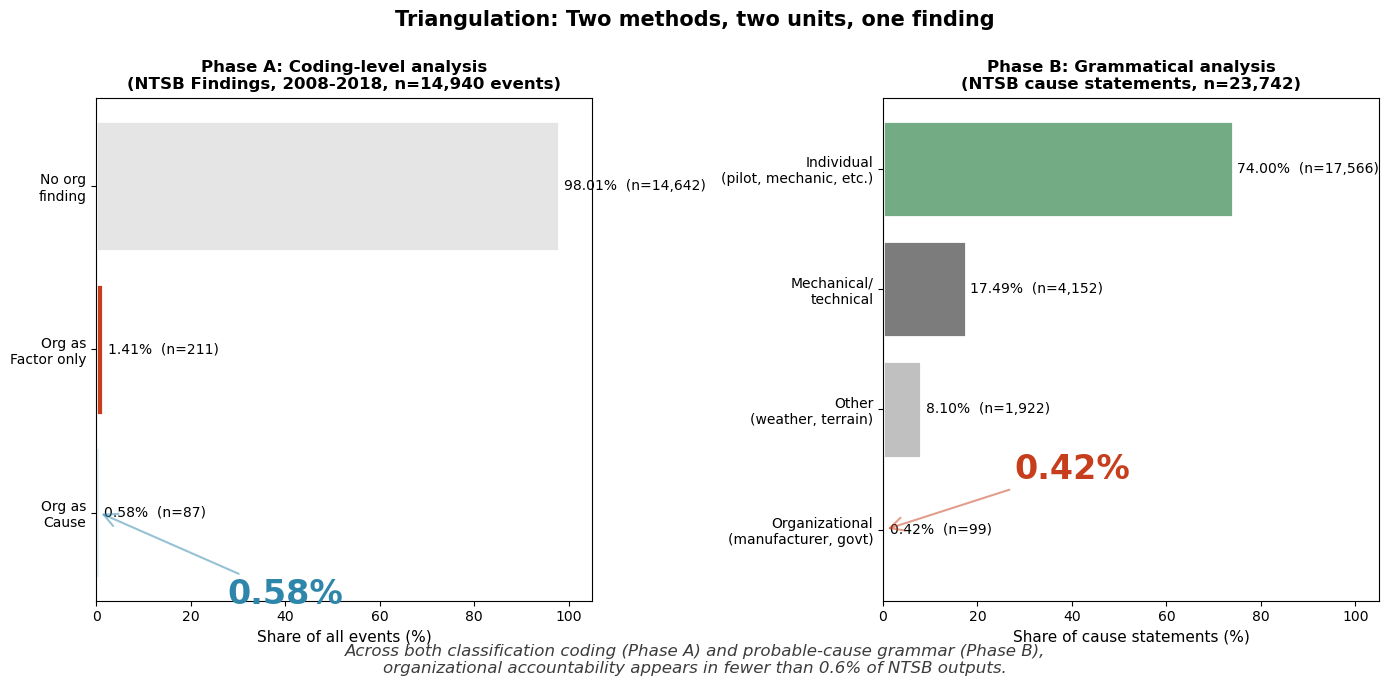

Saved: figure_integration_phase_a_b.png


In [17]:
# Phase A + Phase B integration figure
# The "triangulation" — two independent methods, same finding

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

# ===== PANEL 1: Phase A =====
# 14,940 events, 0.58% organizational as cause
phase_a_data = {
    'No org\nfinding': 14642,
    'Org as\nFactor only': 211,
    'Org as\nCause': 87
}
phase_a_total = sum(phase_a_data.values())
phase_a_pct = {k: v/phase_a_total*100 for k, v in phase_a_data.items()}
phase_a_colors = ['#E5E5E5', '#C73E1D', '#2E86AB']

ax1 = axes[0]
y_pos = np.arange(len(phase_a_data))
labels = list(phase_a_data.keys())
values = [phase_a_pct[k] for k in labels]
counts = [phase_a_data[k] for k in labels]

bars = ax1.barh(y_pos, values, color=phase_a_colors, edgecolor='white', linewidth=2)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Share of all events (%)', fontsize=11)
ax1.set_xlim(0, 105)

# Value labels
for i, (val, count) in enumerate(zip(values, counts)):
    ax1.text(val + 1, i, f'{val:.2f}%  (n={count:,})',
             va='center', fontsize=10)

ax1.set_title('Phase A: Coding-level analysis\n(NTSB Findings, 2008-2018, n=14,940 events)',
              fontsize=12, fontweight='bold')

# Highlight the 0.58%
ax1.annotate('0.58%',
             xy=(0.58, 2), xytext=(40, 2.5),
             fontsize=24, color='#2E86AB', fontweight='bold',
             ha='center', va='center',
             arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1.5, alpha=0.5))

# ===== PANEL 2: Phase B =====
# 23,742 cause statements, 0.42% organizational subject
phase_b_data = {
    'Individual\n(pilot, mechanic, etc.)': 17566,
    'Mechanical/\ntechnical': 4152,
    'Other\n(weather, terrain)': 1922,
    'Organizational\n(manufacturer, govt)': 99
}
phase_b_total = sum(phase_b_data.values())
phase_b_pct = {k: v/phase_b_total*100 for k, v in phase_b_data.items()}
phase_b_colors = ['#73AB84', '#7C7C7C', '#C0C0C0', '#C73E1D']

ax2 = axes[1]
y_pos = np.arange(len(phase_b_data))
labels = list(phase_b_data.keys())
values = [phase_b_pct[k] for k in labels]
counts = [phase_b_data[k] for k in labels]

bars = ax2.barh(y_pos, values, color=phase_b_colors, edgecolor='white', linewidth=2)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels, fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Share of cause statements (%)', fontsize=11)
ax2.set_xlim(0, 105)

for i, (val, count) in enumerate(zip(values, counts)):
    ax2.text(val + 1, i, f'{val:.2f}%  (n={count:,})',
             va='center', fontsize=10)

ax2.set_title('Phase B: Grammatical analysis\n(NTSB cause statements, n=23,742)',
              fontsize=12, fontweight='bold')

# Highlight the 0.42%
ax2.annotate('0.42%',
             xy=(0.42, 3), xytext=(40, 2.5),
             fontsize=24, color='#C73E1D', fontweight='bold',
             ha='center', va='center',
             arrowprops=dict(arrowstyle='->', color='#C73E1D', lw=1.5, alpha=0.5))

# ===== Master title + bottom message =====
fig.suptitle('Triangulation: Two methods, two units, one finding',
             fontsize=15, fontweight='bold', y=1.00)

fig.text(0.5, -0.02,
         'Across both classification coding (Phase A) and probable-cause grammar (Phase B),\n'
         'organizational accountability appears in fewer than 0.6% of NTSB outputs.',
         ha='center', fontsize=12, style='italic', color='#3C3C3C')

plt.tight_layout()
plt.savefig('figure_integration_phase_a_b.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figure_integration_phase_a_b.png")